# 0. Marking.

**_IMPORTANT_**: Save a copy of this notebook into your Drive before you start.

- Please attempt all the questions marked for your group (Part II ✅ | Part III/MPhil ✅).
- Continue to part 2 after you are done with this one.

Please submit a zip file, containing both parts, consiting of of:

1. A text file with a publicly visible link to your notebooks in Google Colab or GitHub.
2. A downloaded copy (ipynb) of your notebooks or your zipped cloned GitHub repo. You may treat these as a report: we will not be re-executing the code you used to produce the answers unless required.

If you find yourself enjoying the material, feel free to attempt more! Provide your answers in a new cell below the question cell.


## Imports


In [1]:
# The simulation component of flower uses RAY under the hood.
# `pip` could produce some errors. Nothing to worry about.
# The execution has been verified; it is working anyway.
# ! pip install --quiet --upgrade "pip"
# ! pip install git+https://github.com/Iacob-Alexandru-Andrei/flower.git@teaching \
#     ray=="2.6.3" torch=="2.2.1" torchvision=="0.17.1"  tqdm=="4.67.1" \
#     torchsummary=="1.5.1" tensorflow-privacy==0.8.6 matplotlib=="3.8.2"

In [2]:
# Imports
import random
from collections.abc import Callable
from copy import deepcopy
from pathlib import Path
from typing import Any
from logging import INFO


import flwr as fl
import numpy as np

import pandas as pd
import torch
from torch import nn
from flwr.common import (
    log,
    MetricsAggregationFn,
)
from flwr.client import Client
from flwr.common.parameter import ndarrays_to_parameters, parameters_to_ndarrays
from flwr.common.typing import NDArrays, Parameters, Scalar
from flwr.server import ServerConfig, History
from flwr.server.server_returns_parameters import ReturnParametersServer as Server
from flwr.server.client_manager import ClientManager
from flwr.server.client_proxy import ClientProxy
from flwr.server.strategy import Strategy
from torch.nn import Module
from torch.utils.data import DataLoader
from enum import IntEnum
from datetime import datetime, timezone
import json

import math


# Add new seeds here for easy autocomplete
class Seeds(IntEnum):
    """Seeds for reproducibility."""

    DEFAULT = 1337


np.random.seed(Seeds.DEFAULT)
random.seed(Seeds.DEFAULT)
torch.manual_seed(Seeds.DEFAULT)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

PathType = Path | str | None

2025-02-24 13:56:07.368976: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 13:56:07.510191: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 13:56:07.512269: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-24 13:56:08.576254: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/dawn/venvs/fed/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-24 13:56:10,300	INFO util.py:

### Paths


In [3]:
home_dir = Path.cwd()
dataset_dir: Path = home_dir / "femnist"
data_dir: Path = dataset_dir / "data"
centralized_partition: Path = dataset_dir / "client_data_mappings" / "centralized"
centralized_mapping: Path = dataset_dir / "client_data_mappings" / "centralized" / "0"
federated_partition: Path = dataset_dir / "client_data_mappings" / "fed_natural"

### Useful Python functions


In [4]:
def convert(o: Any) -> int | float:
    """Convert input object to Python numerical if numpy."""
    # type: ignore[reportGeneralTypeIssues]
    if isinstance(o, np.int32 | np.int64):
        return int(o)
    # type: ignore[reportGeneralTypeIssues]
    if isinstance(o, np.float32 | np.float64):
        return float(o)
    raise TypeError


def save_history(hist: History, name: str) -> None:
    """Save history from simulation to file."""
    time = int(datetime.now(timezone.utc).timestamp())
    path = home_dir / "histories"
    path.mkdir(exist_ok=True)
    path = path / f"hist_{time}_{name}.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(hist.__dict__, f, ensure_ascii=False, indent=4, default=convert)


def start_seeded_simulation(
    client_fn: Callable[[str], Client],
    num_clients: int,
    config: ServerConfig,
    strategy: Strategy,
    name: str,
    seed: int = Seeds.DEFAULT,
    iteration: int = 0,
    server: Server | None = None,
) -> tuple[list[tuple[int, NDArrays]], History]:
    """Wrap simulation to always seed client selection."""
    np.random.seed(seed ^ iteration)
    torch.manual_seed(seed ^ iteration)
    random.seed(seed ^ iteration)
    parameter_list, hist = fl.simulation.start_simulation_no_ray(
        client_fn=client_fn,
        num_clients=num_clients,
        client_resources={},
        config=config,
        strategy=strategy,
        server=server,
    )
    save_history(hist, name)
    return parameter_list, hist

### Dataset


In [5]:
# Decompress dataset
if not dataset_dir.exists():
    !tar -xf {str(home_dir)}/femnist.tar.gz -C {str(home_dir)} 2> /dev/null
    log(INFO, f"Dataset extracted in {dataset_dir}")

In [6]:
from common.client import FlowerClient, get_flower_client_generator
from common.client_manager import CustomClientManager
from common.strategy import DeterministicSampleFedAvg as FedAvgM
from common.client_utils import (
    get_network_generator_cnn,
    get_model_parameters,
    aggregate_weighted_average,
    get_federated_evaluation_function,
    get_default_test_config,
    get_default_train_config,
    get_device,
    DPAdaptiveClipFlagError,
    DPClientNormBitError,
)
from itertools import starmap

# 1. Introduction.


Welcome to the fourth lab session in our FL course. Having explored standard FL, data heterogeneity and device heterogeneity, we now focus on one of FL's main selling points: privacy.

The two methods for achieving privacy we will explore are client-level [**Differential Privacy**](https://ieeexplore.ieee.org/abstract/document/9069945) and [**Secure Aggregation**](https://research.google/pubs/pub45808/). Intuitively, the **first** provides statistical guarantees on how distinguishable a single client's pseudo-gradient is compared to the aggregated pseudo-gradient without its contribution.

<!-- a probabilistic bound on how distinct the final model trained using the data of a given client would be from the same model trained without data from that client (thus if a client contains all samples from a given class, it should be difficult for the model to predict that class as it would have to violate DP).  -->

In an ideal privacy scenario, we would prefer it if two global models trained with or without the data of a given client were indistinguishable.
The **second** is a cryptography-based solution that effectively erases the ability to identify a client during aggregation by encrypting all client model updates to produce the correct aggregate when summed.

As these topics are pretty in-depth, we will not cover them to the same level of detail as previous labs concerning theoretical subjects (such as data heterogeneity in lab 2). This lab will be primarily experimental to test the algorithms put into practice. We will, however, begin with a light introduction. Suppose you are interested in learning more about the subject. In that case, we may recommend the following papers [Deep Learning with Differential Privacy](https://arxiv.org/pdf/1607.00133.pdf) \[1], [Learning Differentially Private Recurrent Language Models](https://arxiv.org/pdf/1710.06963.pdf) \[2] and [Differentially private learning with adaptive clipping](https://arxiv.org/abs/1905.03871) \[3] on the DP front. For secure aggregation consider the original paper [Practical Secure Aggregation for Federated Learning on User-Held Data](https://arxiv.org/pdf/1611.04482.pdf) \[4] and the improved [LightSecAgg](https://arxiv.org/abs/2109.14236) \[5].

Secure aggregation does not harm the model's accuracy and demands only increased communication. Any samples involved in training may still be reconstructed in an attack; however, knowing who contributed the samples will not be possible. Thus, while the implementation is complex, its behaviour is predictable and shall be reserved for the end of the notebook as we are only concerned with measuring communication costs and answering conceptual questions. As such, let us dive into Differential Privacy after the following well-known imports.

> **Important** The entire notebook has been tested in a GPU-enabled Google Colab environment, which runs at around 6 minutes per FL experiment. All experiments require you to vary at most one parameter at a time, so please use a for loop to generate a list of histories rather than trying to manage multiple cells---most experiments rely on one run we create for demonstration purposes to cover one of the desire parameter values. We have purposefully reduced the size of the federated test set significantly and have also reduced the overall number of clients used during FL experimentation. If you are more constrained in your resources (e.g., you have run out of Google accounts that can get a GPU or you get an error peculiar to your exact colab machine), let us know either on Slack or in your submission, and we will either help you set up the code locally, potentially provide you with history objects, or offer take this into account during marking.

Citations:

1.  Abadi, Martin, et al. "Deep learning with differential privacy." Proceedings of the 2016 ACM SIGSAC conference on computer and communications security. 2016.
2.  McMahan, H. Brendan, et al. "Learning differentially private recurrent language models." arXiv preprint arXiv:1710.06963 (2017).
3.  Thakkar, Om, Galen Andrew, and H. Brendan McMahan. "Differentially private learning with adaptive clipping." arXiv e-prints (2019): arXiv-1905.
4.  Bonawitz, Keith, et al. "Practical secure aggregation for federated learning on user-held data." arXiv preprint arXiv:1611.04482 (2016).
5.  So, Jinhyun, et al. "Lightsecagg: a lightweight and versatile design for secure aggregation in federated learning." Proceedings of Machine Learning and Systems 4 (2022): 694-720.


# 2.Deep Learning With Differential Privacy


Before diving into a definition of Differential Privacy adapted to an FL context, we shall begin with the first version of DP applied to Deep Learning based on the aforementioned paper.

The authors of the original extension of _DP to Deep Learning_ justify the need for such a privacy mechanism based on the possibility that an attacker may reconstruct specific samples from the data perfectly in a sensitive context, such as facial recognition, while only having **black-box** access to the trained model. However, their algorithm for DP protects against even adversaries with full knowledge of the training procedure, access to the parameters and potential control over parts of the dataset.

Their **definition** of DP is as follows: a randomised mechanism $M: D ⟶ R$ (a neural network training procedure, in our case) satisfies $(ϵ,δ)$-differential privacy for any $S⊆R$ (a subset of outputs in the range $R$) if $Pr[M(d) \in S] \leq e^{\epsilon} Pr[M(d') \in S] + \delta$ holds, where $d∈D$ and $d'∈D$ are adjacent sets (datasets) of the same domain $D$ (set of all the possible datasets), i.e., they differ by only one record (a training sample, in our case). We can **interpret** this as stating that the probability of getting a particular output from our model when not including a specific sample should be close to the probability of getting the same output had we not included the sample. Specifically, when $\epsilon=0$, the two probabilities are equal, and it is impossible to find out if that sample was included in the training set. The bigger $\epsilon$ is the lower protection is. The probability that the model produces different outputs when trained on adjacent datasets increases exponentially with $\epsilon$.

> Importantly, the original definition of DP and the one you may have encountered before only contained the exponential term _without the_ $\delta$; however, this resulted in _very strong requirements_ for not breaking privacy. This new form, $(\epsilon, \delta)$ privacy relaxed the requirement. Informally, it can be interpreted as allowing privacy at a given $\epsilon$ level to be broken with _probability_ $1-\delta$. We do not have the scale of experimentation necessary to consider both in this lab, as such we will focus on $\epsilon$ values at the detriment of analysing changes in $\delta$. For the experiments in this lab, you can consider DP to be defined entirely in terms of ϵ. Formally, the transition to $(\epsilon, \delta)$ delta was necessary to move from an inefficient noise generation mechanism to Gaussian noise as ML models are much more complex than typical vector-valued functions.


Differentially private **approximations** of functions are usually **constructed** by the addition of noise proportional to the sensitivity of the function---think of it as the maximal impact that the addition or removal of a data point can have upon the output of the function. From now on, we shall refer to this noise level as the **`noise_multiplier`** as it scales the noise multiplicatively based on the sensitivity. When DP was extended to a DL context, making the system differentially private by intervening upon the gradients used during training rather than the final model was significantly more straightforward than operating on the model as a function after training. In the context of ML model updates (gradient descent steps or pseudo-gradients in FL), their sensitivity is generally defined in terms of the l2 norm (when noise is Gaussian) of the update, and the noise is thus scaled based on this norm.

As such, the **original DP-SGD** operates as follows:

1.  _Compute_ the derivative concerning each sample (not minibatch).
2.  _Clip_ the L2 norm of the derivative so it falls below a given bound.
3.  _Aggregate_ these clipped derivatives and _add_ Gaussian _noise_ to obfuscate the impact of specific samples used to compute the gradients. Here, the noise is proportional to the L2 bound.

Suppose we reframe DP to the original context of databases and records. In that case, the larger the number of noisy answers the database offers, the more an attacker can eliminate the noise by looking at the entire distribution of answers. Similarly, the more samples out of the total an ML model sees (or the more times it sees the same sample), the more the noise of the sample gradients average out. For a model to be trained for an extended period, it is thus necessary to use a higher `noise_multiplier`. We shall soon extend this trade-off to clients within an FL context.

While this process operates reasonably in the context of centralised, applying DP-SGD on every client in FL is **problematic**, given the reduced efficiency of the training method. As a result of this inefficiency, the federated model will likely incur significant drops in its already low performance. Furthermore, multiple studies have confirmed that applying DP locally has disastrous effects on the accuracy of the final federated model.


# 3.User-level Differential Privacy


Differential privacy at a client/user level in FL follows the same **definition**, except adjacent datasets are constructed by adding or removing all samples from a given client. Thus, under _maximum privacy scenarios_, with $\epsilon=0$ and $\delta=0$, two models should behave identically regardless of the presence of a specific user in the federation. For user-level DP, training with more users (rather than samples) results in the degradation of privacy. Thus, the **`noise_multiplier`** necessary to make an FL system differentially private with respect to an L2 norm bound depends on the total number of users, the number of users sampled every round and the number of rounds.

**DP-FedAvg** represents a reasonably direct analogue to DP-SGD as it applies the same process to FL pseudo-gradients that DP-SGD applies to gradients generated by one sample. Namely, it clips the gradients based on the L2 norm on the local client after training. The server then adds Gaussian noise related to the L2 norm bound via the `noise_multiplier` when it receives the gradients.

However, this extension is hampered by the fact that DP-SGD assumes an IID distribution of samples. As we, clients in FL contain **non-IID data** and have skewed numbers of samples. As such, for the theoretical privacy guarantee to hold DP-FedAvg **must assume** that _clients will not drop_ out and that the overall set of available clients in the population is static---both being significant limitations. Furthermore, _unweighted aggregation_ is usually enforced since weighted aggregation is more likely to leak data from a specific user. An _additional note_ worth making is that even when violating the theoretical assumptions of DP, applying noise and clipping gradients is still likely to make reconstructing data belonging to a specific client more difficult in practice.

One final theoretical concern worth addressing prior to experimentation is the **nature of the L2 norm clipping**. Two specific _questions_ arise in the early works discussing DP-FedAvg:

- Should the clipping be done per layer or uniformly across the entire model? Consider scenarios where a single large layer encodes all the relevant information about a specific user and is not clipped because the overall L2 norm of the gradient is lower than a generic bound.
- How should a L2 bound be chosen and changed? If the model updates are too small, the model is less likely to learn. However, a more oversized bound implies more noise and thus leads to potential degradation yet again.

These questions have been answered by follow-up work. On the _first point_, this stack overflow answer by one of the authors of paper \[3] above indicates that per-layer bounding leads to worse performance as it is harsher for little benefit. On the _second point_, methods for efficiently tracking a given quantile of the L2 distribution amongst client updates were proposed in \[3]. We will glance at this adaptive mechanism in today's lab but shall not examine it in detail.


**Question 1 (Part II ✅ | Part III/MPhil ✅):**

(This is a conceptual question. Please do not provide more than three sentences per sub-question.)

Consider two applications of FL, next-word prediction and image classification based on personal user data from smartphones.

1. What kind of sensitive information could be extracted from models trained on these tasks?

Next-word prediction: The training weights would reflect statistical properties of the user's used word frequency distribution. Also, the model may be trained to predict words containing users' personal information, so a malicious party could for example use the model to perform inference on "Here are my bank details" and the model might give the actual bank details.

Image classification: Again, statistical properties of the user's personal gallery are reflected in the model weights; a malicious party could for example use the model to perform inference on several face pictures, and the pictures that the model responds more strongly to are more likely to be in the user's gallery.


2. How would DP help preserve privacy for each task when applied on a per-sample versus per-client-dataset level?

Per sample: By definition of DP, this implementation strongly ensures privacy because noise is added to every sample, and because of the clipping, the contribution of every sample to the model is even. Hence for every sample, it is hard to discern which dataset it came from. This applies even if samples are very heterogenous and the weights are skewed.

Per-client-dataset: In this implementation the noise is applied to each client (after aggregating the gradients from each sample), so the noise is large enough to ensure that the output (including noise) would not significantly change if any sample were included or excluded. In this way it makes the samples indistinguishable as well, but does not work well if the samples are very heterogenous and the weights are skewed.

## 3.1 Fixed Norm Bound DP

Given the highly abstract definition of privacy that DP uses, could you think of ways to test the effectiveness of DP practically?


We shall begin by implementing the `DPFedAvg` strategy based on the description above using a static bound on the L2 norm of clients. While we could near-effortlessly add client-level Differential Privacy by using wrappers provided by Flower, implementing its components should be straightforward and informative.

The first cell provides utilities for gradient clipping and noise injection. The clipping operates via simple multiplication.


In [7]:
def compute_model_delta(
    trained_parameters: NDArrays, og_parameters: NDArrays
) -> NDArrays:
    """Compute the delta between two sets of parameters."""
    return list(
        starmap(np.subtract, zip(trained_parameters, og_parameters, strict=True))
    )


def compute_norm(update: NDArrays) -> float:
    """Compute the l2 norm of a parameter update.

    It will account for mismatched NumPy array shapes, to be used in clipping.
    """
    flat_update = update[0]
    for i in range(1, len(update)):
        flat_update = np.append(flat_update, update[i])
    squared_update = np.square(flat_update)
    norm_sum = np.sum(squared_update)
    norm = np.sqrt(norm_sum)
    return norm


def clip_by_l2(update: NDArrays, threshold: float) -> tuple[NDArrays, bool]:
    """Scales the update so thats its L2 norm is upper-bound to threshold."""
    update_norm = compute_norm(update)
    scaling_factor = min(1, threshold / update_norm)
    update_clipped: NDArrays = [layer * scaling_factor for layer in update]
    return update_clipped, (scaling_factor < 1)


def add_gaussian_noise(update: NDArrays, std_dev: float) -> NDArrays:
    """Add Gaussian noise to each floating point value."""
    update_noised = [
        layer + np.random.normal(0, std_dev, layer.shape) for layer in update
    ]
    return update_noised

These components are all we need to design a DP client which can add noise to its updates according to parameters received from the strategy. According to the evaluated threat model, the flower implementation allows noise injection to be equivalently done on the client or server. We shall assume a trustworthy server for this lab and eschew adding noise on the clients.

The client training procedure shall follow the description above verbatim and proceed as follows:

1.  The client receives the parameters and standard configuration arguments as in previous labs.
2.  It also receives a maximum bound on the L2 norm of the trained model.
3.  The model is trained, and the client computes the delta or **update** between its parameters and the original ones received.
4.  The client computes the ratio between the L2 norm of its local update and the maximum it received. It then rescales all the weights in the update by this ratio, so the final norm is at-most the bound---since $||\alpha \times w||_2 = |\alpha| \times ||w||_2$.
5.  The client applies the clipped update to the original parameters and potentially adds Gaussian noise---if this does not already happen on the server---before returning them.


In [8]:
np.random.seed(Seeds.DEFAULT)
random.seed(Seeds.DEFAULT)
torch.manual_seed(Seeds.DEFAULT)
network_generator_cnn = get_network_generator_cnn()
seed_net_cnn = network_generator_cnn()
seed_model_cnn_params: NDArrays = get_model_parameters(seed_net_cnn)
federated_evaluation_function = get_federated_evaluation_function(
    data_dir=data_dir,
    centralized_mapping=centralized_mapping,
    device=get_device(),
    batch_size=get_default_test_config()["batch_size"],
    num_workers=get_default_test_config()["num_workers"],
    model_generator=network_generator_cnn,
    criterion=nn.CrossEntropyLoss(),
)

INFO flwr 2025-02-24 13:56:12,662 | client_utils.py:423 | Reduced federated test_set size from 28510 to a size of 1500 mean index: 14726.628666666667


In [9]:
# If threshold is below computed norm of the weights (wherever they came from),
# Clipping has to happen.
# "clipped" output indicates whether it happened

# If not clipped on client, it WILL be clipped on the server (why?)
# What if there are some clients which got clipped and some which didnt?
# Will another clipping be necessary? If so, isnt it cheating to do 2 clippings?

In [10]:
# Based on the original implementation by Vasundhara Agarwal
class DPFlowerRayClient(FlowerClient):
    """Extends the FlowerClient class to implement DP-FedAvg."""

    def fit(
        self, parameters: NDArrays, config: dict[str, Scalar], **kwargs: dict[str, Any]
    ) -> tuple[NDArrays, int, dict]:
        """Receive and train a model on the local client data.

        It uses parameters from the config dict while injecting gaussian noise into the
        parameter update.

        Args:
            net (NDArrays): Pytorch model parameters
            config (dict[str, Scalar]): Dictionary describing the training parameters

        Returns
        -------
            tuple[NDArrays, int, dict]: Returns the updated model, the size of the
                local dataset and other metrics
        """
        # Create a copy of the initial parameters
        og_parameters = deepcopy(parameters)

        # Only create model right before training/testing
        # To lower memory usage when idle
        net = self.set_parameters(parameters)
        net.to(self.device)
        train_loader: DataLoader = self._create_data_loader(
            config, name="train", **kwargs
        )
        train_loss = self._train(
            net, train_loader=train_loader, config=config, **kwargs
        )

        # Metrics dict since the DP strategy requires an indicator
        # to be returned if the model updates was not clipped on the client
        # and should be clipped on the server
        metrics = {"train_loss": train_loss}

        trained_parameters = get_model_parameters(net)
        # Calculate the delta between the two models
        model_update = list(
            starmap(np.subtract, zip(trained_parameters, og_parameters, strict=True))
        )

        # We will also return the unclipped L2 norm of the delta
        metrics['l2_norm'] = compute_norm(model_update)

        # Clip the delta so all of the updates fall below the same norm
        model_update, was_clipped = clip_by_l2(model_update, config["dpfedavg_clip_norm"])

        if "dpfedavg_noise_stddev" in config:
            # Noising
            model_update = add_gaussian_noise(
                model_update, config["dpfedavg_noise_stddev"]
            )

        for i, _ in enumerate(og_parameters):
            trained_parameters[i] = og_parameters[i] + model_update[i]

        # Calculating value of norm indicator bit, required for adaptive clipping
        if "dpfedavg_adaptive_clip_enabled" in config:
            if not isinstance(config["dpfedavg_adaptive_clip_enabled"], bool):
                raise DPAdaptiveClipFlagError(
                    "dpfedavg_adaptive_clip_enabled should be a boolean-valued flag."
                )
            metrics["dpfedavg_norm_bit"] = not was_clipped

        return trained_parameters, len(train_loader), metrics

The following cell will construct a generator for this client class capable of filtering participants with less than one batch of data. This is necessary to avoid failures as "DPFedAvg" is not tolerant of dropouts.


In [11]:
fl_client_gen = get_flower_client_generator(
    network_generator_cnn, federated_partition, data_dir
)
client_to_num_sample: list[tuple[int, int]] = [
    (cid, fl_client_gen(i).get_train_set_size()) for i, cid in enumerate(range(3229))
]
client_samples_dataframe = pd.DataFrame(
    client_to_num_sample, columns=["cid", "n_samples"]
)

# Remove clients with less than 32 samples corresponding to the default batch size
min_n_samples = 32
client_samples_dataframe = client_samples_dataframe.drop(
    client_samples_dataframe[client_samples_dataframe.n_samples < min_n_samples].index,
)
client_samples_dataframe.reset_index(drop=True)
num_total_clients = len(client_samples_dataframe)
log(INFO, "Num total clients: %s", num_total_clients)


def get_dp_client_generator(
    model_generator: Callable[[], Module],
    data_dir: Path,
    partition_dir: Path,
    mapping_fn: Callable[[int], int] | None = lambda x: client_samples_dataframe.cid[x],
) -> Callable[[str], FlowerClient]:
    """Wrap function for the client instance generator.

    This provides the client generator with a model generator function.
    Also, the partition directory must be passed.
    A mapping function could be used for filtering/ordering clients.

    Args:
        data_dir (Path): path to the dataset folder.
        model_generator (Callable[[], Module]): model generator function.
        partition_dir (Path): directory containing the partition.
        mapping_fn (Optional[Callable[[int], int]]): function mapping sorted/filtered
            ids to real cid.

    Returns
    -------
        Callable[[str], FlowerRayClient]: client instance.
    """

    def client_fn(cid: str) -> DPFlowerRayClient:
        """Create a single client instance given the client id `cid`.

        Args:
            cid (str): client id, Flower requires this to of type str.

        Returns
        -------
            FlowerRayClient: client instance.
        """
        return DPFlowerRayClient(
            cid=mapping_fn(int(cid)) if mapping_fn is not None else int(cid),
            data_dir=data_dir,
            partition_dir=partition_dir,
            model_generator=model_generator,
        )

    return client_fn

INFO flwr 2025-02-24 13:56:12,696 | client.py:51 | Creating client with cid: 0
INFO flwr 2025-02-24 13:56:12,698 | client.py:51 | Creating client with cid: 1
INFO flwr 2025-02-24 13:56:12,699 | client.py:51 | Creating client with cid: 2
INFO flwr 2025-02-24 13:56:12,701 | client.py:51 | Creating client with cid: 3
INFO flwr 2025-02-24 13:56:12,703 | client.py:51 | Creating client with cid: 4
INFO flwr 2025-02-24 13:56:12,704 | client.py:51 | Creating client with cid: 5
INFO flwr 2025-02-24 13:56:12,706 | client.py:51 | Creating client with cid: 6
INFO flwr 2025-02-24 13:56:12,707 | client.py:51 | Creating client with cid: 7
INFO flwr 2025-02-24 13:56:12,708 | client.py:51 | Creating client with cid: 8
INFO flwr 2025-02-24 13:56:12,710 | client.py:51 | Creating client with cid: 9
INFO flwr 2025-02-24 13:56:12,712 | client.py:51 | Creating client with cid: 10
INFO flwr 2025-02-24 13:56:12,713 | client.py:51 | Creating client with cid: 11
INFO flwr 2025-02-24 13:56:12,714 | client.py:51 |

This DP client encapsulates all the meaningful work required for client-level differential privacy to be carried out. However, the strategy controls the L2 norm bound and the noise multiplier used to determine the Gaussian noise standard deviation based on this bound.

We shall now implement a strategy capable of orchestrating DP clients in a manner which best preserves privacy within a given budget.


In [12]:
from collections.abc import Callable

from logging import INFO

import numpy as np

from flwr.common import (
    FitIns,
    FitRes,
    NDArrays,
    Scalar,
)
from flwr.common.logger import log
from math import sqrt


# Based on the original implementation by Vasundhara Agarwal
class DPFedAvgFixed(FedAvgM):
    """Configurable FedAvg strategy implementation."""

    # pylint: disable=too-many-arguments,too-many-instance-attributes,line-too-long
    def __init__(
        self,
        *,
        fraction_fit: float = 1.0,
        fraction_evaluate: float = 1.0,
        min_fit_clients: int = 2,
        min_evaluate_clients: int = 2,
        min_available_clients: int = 2,
        evaluate_fn: (
            Callable[
                [int, NDArrays, dict[str, Scalar]],
                tuple[float, dict[str, Scalar]] | None,
            ]
            | None
        ) = None,
        on_fit_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        on_evaluate_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        accept_failures: bool = False,
        initial_parameters: Parameters | None = None,
        fit_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        evaluate_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        server_learning_rate: float = 1.0,
        server_momentum: float = 0.0,
        num_clients_per_round: int,
        clip_norm: float,
        noise_multiplier: float = 1,
        server_side_noising: bool = True,
    ) -> None:
        super().__init__(
            fraction_fit=fraction_fit,
            fraction_evaluate=fraction_evaluate,
            min_fit_clients=min_fit_clients,
            min_evaluate_clients=min_evaluate_clients,
            min_available_clients=min_available_clients,
            evaluate_fn=evaluate_fn,
            on_fit_config_fn=on_fit_config_fn,
            on_evaluate_config_fn=on_evaluate_config_fn,
            accept_failures=accept_failures,
            initial_parameters=initial_parameters,
            fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
            evaluate_metrics_aggregation_fn=evaluate_metrics_aggregation_fn,
            server_learning_rate=server_learning_rate,
            server_momentum=server_momentum,
        )
        # Doing fixed-size subsampling as in https://arxiv.org/abs/1905.03871
        self.num_clients_per_round = num_clients_per_round
        self.noise_multiplier = noise_multiplier
        self.server_side_noising = server_side_noising
        self.clip_norm = clip_norm

    # Automatically calculate the standard deviation of the noise
    # Based on the clip norm and number of clients per round
    # The noise multiplier controls the number of standard deviations from the mean
    def _calc_client_noise_stddev(self) -> float:
        stddev = (
            self.noise_multiplier * self.clip_norm / (sqrt(self.num_clients_per_round))
        )
        return float(stddev)

    def configure_fit(
        self,
        server_round: int,
        parameters: Parameters,
        client_manager: CustomClientManager,
    ) -> list[tuple[ClientProxy, FitIns]]:
        """Configure the next round of training."""
        config = {}
        if self.on_fit_config_fn is not None:
            # Custom fit config function provided
            config = self.on_fit_config_fn(server_round)

        # Add DP info to config for local update clipping
        config["dpfedavg_clip_norm"] = self.clip_norm
        if not self.server_side_noising:
            config["dpfedavg_noise_stddev"] = self._calc_client_noise_stddev()
        fit_ins = FitIns(parameters, config)

        # Sample clients
        sample_size, min_num_clients = self.num_fit_clients(
            client_manager.num_available()
        )
        clients = client_manager.sample(
            num_clients=sample_size,
            min_num_clients=min_num_clients,
            server_round=server_round,
        )

        # Return client/config pairs
        return [(client, fit_ins) for client in clients]

    def aggregate_fit(
        self,
        server_round: int,
        results: list[tuple[ClientProxy, FitRes]],
        failures: list[tuple[ClientProxy, FitRes] | BaseException],
    ) -> tuple[Parameters | None, dict[str, Scalar]]:
        """Aggregate the results of the training round."""
        if failures and not self.accept_failures:
            return None, {}
        # Forcing unweighted aggregation, as in https://arxiv.org/abs/1905.03871
        # By setting the number of examples associated to each model
        # To 1
        for _, fit_res in results:
            fit_res.num_examples = 1
            if self.server_side_noising:
                fit_res.parameters = ndarrays_to_parameters(
                    add_gaussian_noise(
                        parameters_to_ndarrays(fit_res.parameters),
                        self._calc_client_noise_stddev(),
                    )
                )

        return super().aggregate_fit(server_round, results, failures)

Do observe how the unweighted aggregation combines with the norm clipping to limit the disproportionate impact of high-data clients upon the federated model to treat all clients close-to-equally regarding privacy leaks.

We can now create a function to run such experiments, allowing you to easily maintain and change default parameters as needed.


In [13]:
from typing import List, Tuple, Dict

dp_client_generator = get_dp_client_generator(
    network_generator_cnn,
    data_dir,
    federated_partition,
    lambda x: client_samples_dataframe.cid[x],
)
default_parameters: dict = {
    "train_config": get_default_train_config(),
    "test_config": get_default_test_config(),
    "num_total_clients": num_total_clients,
    "num_clients_per_round": 4,
    "num_evaluate_clients": 0,
    "num_evaluate": 0,
    "accept_failures": False,
    "min_fit_clients": 2,
    "min_available_clients": 2,
    "initial_parameters": ndarrays_to_parameters(seed_model_cnn_params),
    "client_generator": dp_client_generator,
    "seed": Seeds.DEFAULT,
    "num_rounds": 30,
    "strategy": DPFedAvgFixed,
    "fed_eval": True,
    "server_side_noising": True,
}

def run_dp_fixed_fl(
    clip_norm: float = 4.0,
    noise_multiplier: float = 0.05,
    default_parameters: dict = default_parameters,
    **kwargs: dict[str, Any],
) -> Any:
    """Execute a DP-FedAvg simulation with fixed clip norm and noise multiplier."""
    parameters: dict = {**default_parameters, **kwargs}

    def on_fit_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["train_config"]

    def on_evaluate_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["test_config"]

    fraction_fit: float = (
        float(parameters["num_clients_per_round"]) / parameters["num_total_clients"]
    )
    fraction_evaluate: float = (
        float(parameters["num_evaluate_clients"]) / parameters["num_total_clients"]
    )

    strategy = parameters["strategy"](
        num_clients_per_round=parameters["num_clients_per_round"],
        fraction_fit=fraction_fit,
        fraction_evaluate=fraction_evaluate,
        min_fit_clients=parameters["min_fit_clients"],
        min_available_clients=parameters["min_available_clients"],
        on_fit_config_fn=on_fit_config_fn,
        on_evaluate_config_fn=on_evaluate_config_fn,
        initial_parameters=parameters["initial_parameters"],
        accept_failures=parameters["accept_failures"],
        evaluate_fn=(
            federated_evaluation_function if parameters["fed_eval"] is True else None
        ),
        fit_metrics_aggregation_fn = aggregate_weighted_average,
        evaluate_metrics_aggregation_fn = aggregate_weighted_average,
        clip_norm=clip_norm,
        noise_multiplier=noise_multiplier,
        server_side_noising=parameters["server_side_noising"],
    )
    client_manager = CustomClientManager(criterion=None, seed=parameters["seed"])
    server = Server(
        client_manager=client_manager,
        strategy=strategy,
    )
    return start_seeded_simulation(
        client_fn=lambda cid: parameters["client_generator"](cid).to_client(),
        num_clients=parameters["num_total_clients"],
        server=server,
        config=ServerConfig(num_rounds=parameters["num_rounds"]),
        strategy=strategy,
        seed=parameters["seed"],
        name=f"fixed_clip_norm_{clip_norm}_noise_{noise_multiplier}",
    )

In [14]:
parameters_for_every_round, hist_clip_bound_4_noise_0_05 = run_dp_fixed_fl(4)

WARNING flwr 2025-02-24 13:56:17,088 | app.py:213 | Both server and strategy were provided, ignoring strategy
INFO flwr 2025-02-24 13:56:17,089 | app.py:149 | Starting Flower simulation, config: ServerConfig(num_rounds=30, round_timeout=None)
INFO flwr 2025-02-24 13:56:17,098 | server_returns_parameters.py:81 | Initializing global parameters
INFO flwr 2025-02-24 13:56:17,099 | server_returns_parameters.py:273 | Using initial parameters provided by strategy
INFO flwr 2025-02-24 13:56:17,101 | server_returns_parameters.py:84 | Evaluating initial parameters
100%|██████████| 47/47 [00:00<00:00, 126.19it/s]
INFO flwr 2025-02-24 13:56:17,486 | server_returns_parameters.py:87 | initial parameters (loss, other metrics): 194.3757643699646, {'accuracy': 0.004}
INFO flwr 2025-02-24 13:56:17,486 | server_returns_parameters.py:97 | FL starting
INFO flwr 2025-02-24 13:56:17,487 | client_manager.py:43 | Sampling using None
INFO flwr 2025-02-24 13:56:17,488 | client_manager.py:68 | Sampled the followi

In [15]:
hist_clip_bound_4_noise_0_05

History (loss, centralized):
	round 0: 194.3757643699646
	round 1: 186.5846586227417
	round 2: 179.64194130897522
	round 3: 173.43598651885986
	round 4: 160.12183165550232
	round 5: 146.61857271194458
	round 6: 131.79804348945618
	round 7: 126.95562195777893
	round 8: 123.44766402244568
	round 9: 120.15659952163696
	round 10: 116.79804956912994
	round 11: 108.23453497886658
	round 12: 115.7263023853302
	round 13: 122.9894950389862
	round 14: 123.71360528469086
	round 15: 98.40278470516205
	round 16: 109.4586900472641
	round 17: 122.6478887796402
	round 18: 127.71150946617126
	round 19: 140.93981289863586
	round 20: 126.37663519382477
	round 21: 122.62985694408417
	round 22: 120.56699597835541
	round 23: 124.79775333404541
	round 24: 117.89066958427429
	round 25: 133.7383918762207
	round 26: 132.54199743270874
	round 27: 119.58367478847504
	round 28: 133.03602766990662
	round 29: 135.8488894701004
	round 30: 127.6026177406311
History (metrics, distributed, fit):
{'train_loss': [(1, {'av

**Question 3 (Part II ✅ | Part III/MPhil ✅):**

(You must provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

Norm-clipping is an often-used technique in FL that resembles the previously discussed FedProx---or FedAvg with a `server_learning_rate<1.0`. When it is used to tackle data heterogeneity, it limits the divergence of highly heterogeneous clients. In the context of privacy, more significant updates are likely to come from either larger or more heterogeneous clients. Thus, when combined with unweighted aggregation, norm clipping stabilises training. However, it may slow down improvements in accuracy.

> It is important to note that, theoretically, the triangle inequality assures us that the overall federated model update will have a norm below `clip_norm`.

You will now examine the effects of norm-clipping on model accuracy irrespective of noise.

1. Use one round of federated training with `num_clients_per_round=50` to empirically derive a **very rough baseline** of the average L2 norm at the beginning of training. Modify the client `fit` function to return in the metrics dictionary the L2 norm of the model update **prior** to clipping. Finally, compute the mean $\mu$ of the L2 norms from all of the 50 clients. You can find them in the history object returned in the "all" category of the metric. _NOTE: do not use the "avg" category because it is weighted._

   > The results of this question will be used in the next one. Thus, to save yourself work, modify the strategy object. Make it compute the L2 norm of the overall model delta. This delta is defined as the difference between the federated model at the start of the round and the federated model after aggregation. Put the value of the L2 norm of the delta into the history object as a metric into the already aggregated metrics object. (The strategy has access to the starting parameters of a round in `configure_fit` as well as the aggregated metrics of all the clients.)


I changed the client fit function to return the norm of the model update prior to clipping.

In [16]:
params = {**default_parameters}
params['num_rounds'] = 1
params['num_clients_per_round'] = 50

_, q1hist = run_dp_fixed_fl(default_parameters=params)

WARNING flwr 2025-02-24 13:57:44,035 | app.py:213 | Both server and strategy were provided, ignoring strategy
INFO flwr 2025-02-24 13:57:44,036 | app.py:149 | Starting Flower simulation, config: ServerConfig(num_rounds=1, round_timeout=None)
INFO flwr 2025-02-24 13:57:44,046 | server_returns_parameters.py:81 | Initializing global parameters
INFO flwr 2025-02-24 13:57:44,047 | server_returns_parameters.py:273 | Using initial parameters provided by strategy
INFO flwr 2025-02-24 13:57:44,050 | server_returns_parameters.py:84 | Evaluating initial parameters
100%|██████████| 47/47 [00:00<00:00, 127.26it/s]
INFO flwr 2025-02-24 13:57:44,426 | server_returns_parameters.py:87 | initial parameters (loss, other metrics): 194.3757643699646, {'accuracy': 0.004}
INFO flwr 2025-02-24 13:57:44,427 | server_returns_parameters.py:97 | FL starting
INFO flwr 2025-02-24 13:57:44,429 | client_manager.py:43 | Sampling using None
INFO flwr 2025-02-24 13:57:44,429 | client_manager.py:68 | Sampled the followin

Then I simply compiled the 50 l2 norms and averaged them. Stored in variable mu.

In [17]:
mu = np.array([norm for _, norm in q1hist.metrics_distributed_fit['l2_norm'][0][1]['all']]).mean()
print(mu)

10.244001


2. Using values of `clip_norm`$\in \{ \mu \times 0.25,\, \mu, \,\mu \times 1.75\}$, run `DPFedAvgFixed` experiments with the same parameters as the example provided above using a `noise_multiplier=0`.

Aside from storing the resulting weights and histories, I stored the accuracies for part 3.

In [18]:
parameters = {}
histories = {}
clip_norm_coefficients = [0.25, 1, 1.75]
accuracies = {}

for m in clip_norm_coefficients:
  parameters_for_rounds, hist  = run_dp_fixed_fl(
    clip_norm = m * mu,
    noise_multiplier = 0,
  )
  parameters[m] = parameters_for_rounds
  histories[m] = hist
  accuracies[m] = hist.metrics_centralized['accuracy']

WARNING flwr 2025-02-24 13:58:25,539 | app.py:213 | Both server and strategy were provided, ignoring strategy
INFO flwr 2025-02-24 13:58:25,541 | app.py:149 | Starting Flower simulation, config: ServerConfig(num_rounds=30, round_timeout=None)
INFO flwr 2025-02-24 13:58:25,549 | server_returns_parameters.py:81 | Initializing global parameters
INFO flwr 2025-02-24 13:58:25,551 | server_returns_parameters.py:273 | Using initial parameters provided by strategy
INFO flwr 2025-02-24 13:58:25,554 | server_returns_parameters.py:84 | Evaluating initial parameters
100%|██████████| 47/47 [00:00<00:00, 125.12it/s]
INFO flwr 2025-02-24 13:58:25,935 | server_returns_parameters.py:87 | initial parameters (loss, other metrics): 194.3757643699646, {'accuracy': 0.004}
INFO flwr 2025-02-24 13:58:25,935 | server_returns_parameters.py:97 | FL starting
INFO flwr 2025-02-24 13:58:25,937 | client_manager.py:43 | Sampling using None
INFO flwr 2025-02-24 13:58:25,937 | client_manager.py:68 | Sampled the followi

In [19]:
accuracies

{0.25: [(0, 0.004),
  (1, 0.07933333333333334),
  (2, 0.07933333333333334),
  (3, 0.07933333333333334),
  (4, 0.07933333333333334),
  (5, 0.1),
  (6, 0.08133333333333333),
  (7, 0.15666666666666668),
  (8, 0.20533333333333334),
  (9, 0.246),
  (10, 0.30933333333333335),
  (11, 0.35333333333333333),
  (12, 0.384),
  (13, 0.422),
  (14, 0.454),
  (15, 0.48733333333333334),
  (16, 0.504),
  (17, 0.5066666666666667),
  (18, 0.5086666666666667),
  (19, 0.53),
  (20, 0.552),
  (21, 0.5553333333333333),
  (22, 0.5613333333333334),
  (23, 0.5773333333333334),
  (24, 0.5773333333333334),
  (25, 0.5733333333333334),
  (26, 0.5986666666666667),
  (27, 0.626),
  (28, 0.6186666666666667),
  (29, 0.626),
  (30, 0.6073333333333333)],
 1: [(0, 0.004),
  (1, 0.07933333333333334),
  (2, 0.07133333333333333),
  (3, 0.21066666666666667),
  (4, 0.33266666666666667),
  (5, 0.38866666666666666),
  (6, 0.42133333333333334),
  (7, 0.5353333333333333),
  (8, 0.46266666666666667),
  (9, 0.5173333333333333),
  (1

3. Plot per-round accuracy on the federated test set of models trained using the three bounds above. Which bound converges the fastest and to the highest final accuracy, and why do you think that is?

In [20]:
import pandas as pd

def dict_to_df(dict):
    """
    Converts dictionary of clip coefficients and their corresponding values (eg accuracy)
    into a pandas DataFrame.
    """
    df = pd.DataFrame()
    for coefficient, tuples in dict.items():
        # Add a new column to the DataFrame,
        # corresponding to the coefficient and its accuracy values
        df[coefficient] = [value for round_id, value in tuples]
    return df


def plot_clip_coefficient_dict(dic, **kwargs):
    df = dict_to_df(dic)
    return df.plot(**kwargs)

<Axes: title={'center': 'Accuracies per round'}, xlabel='Round Number', ylabel='Accuracy'>

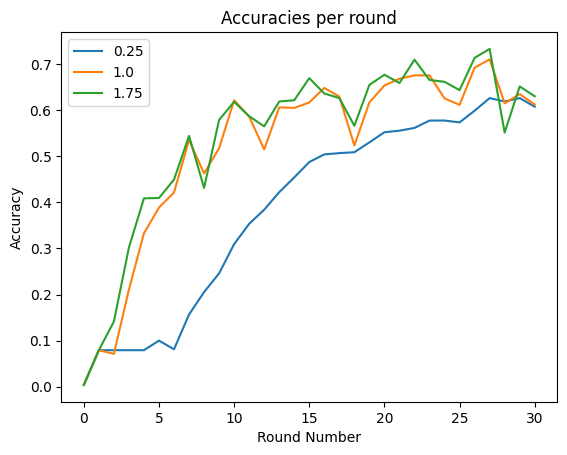

In [21]:
plot_clip_coefficient_dict(accuracies, title='Accuracies per round', xlabel='Round Number', ylabel='Accuracy')

My understanding is that when the coefficient is 1, we are using our estimation of the average clip norm (from the previous question) as a threshold for clipping, so it clips around half of the gradients. Following that logic, with the coefficient of 0.25 clipping will almost always happen, and with 1.75 clipping will almost never happen.

Since 1.75 coefficient allows some clients to have disproportionately large impact on the model update, it tends to be more unstable. In contrast, 0.25 coefficient always clips gradients which makes the model update more stable but convergence takes longer.

**Question 4 (Part II ✅ | Part III/MPhil ✅):**

(You must provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

This question extends the one above to investigate the effect that the `clip_norm` has upon the norm of the federated model update. The federated model update is defined as the difference between the model at the start of the round and the model post-aggregation.

1. Using the results from the above question, plot the following:

   - The L2 norm of the federated model deltas across rounds for the three bounds above. How does L2 norm of the federated model delta compare to `clip_norm` (draw a horizontal line for all three bounds)? Is the behaviour as you expected, and why/why not?
   - The accuracy on the federated test set of models trained using the three norms above against the cumulative L2 norm accumulated across rounds as the axis. Consider the accuracy of the initial parameter test (round 0) to map to an L2 norm of 0. By cumulative L2, we mean a running sum where you keep adding the new norm value to the sum and then add the sum to a per-round list. Such a sum can easily be computed from a list using a `accumulate()` call.


In [22]:
histories.items()

dict_items([(0.25, History (loss, centralized):
	round 0: 194.3757643699646
	round 1: 190.09559726715088
	round 2: 183.72052478790283
	round 3: 170.41061878204346
	round 4: 168.74501657485962
	round 5: 164.37118816375732
	round 6: 162.1720323562622
	round 7: 156.80425882339478
	round 8: 152.4864718914032
	round 9: 145.01436352729797
	round 10: 134.73480010032654
	round 11: 124.77406239509583
	round 12: 115.1326756477356
	round 13: 104.75659203529358
	round 14: 99.43799352645874
	round 15: 95.68784034252167
	round 16: 94.61279094219208
	round 17: 97.009730219841
	round 18: 97.08816885948181
	round 19: 94.55454969406128
	round 20: 92.76865357160568
	round 21: 92.26163184642792
	round 22: 90.66020339727402
	round 23: 91.25576996803284
	round 24: 93.29452735185623
	round 25: 90.42758929729462
	round 26: 85.90621715784073
	round 27: 79.12275826931
	round 28: 78.41637200117111
	round 29: 78.47822231054306
	round 30: 81.77771824598312
History (metrics, distributed, fit):
{'train_loss': [(1, {

For each round I used the weighted averaged l2_norm (under the 'avg' category) 

In [26]:
l2_norms = {
    clip_coefficient: [(0, 0)] + [
        (round_id, round_l2_norms['avg']) for round_id, round_l2_norms in history.metrics_distributed_fit['l2_norm']
    ] for clip_coefficient, history in histories.items()
}
print(l2_norms)

{0.25: [(0, 0), (1, 9.601118087768555), (2, 6.200057938904681), (3, 4.934900687706876), (4, 10.143377830482374), (5, 10.865586499986701), (6, 13.07620100252064), (7, 11.13104842649086), (8, 13.917245492787526), (9, 11.579663698806716), (10, 13.090255103850364), (11, 13.508775174982098), (12, 13.1224298641989), (13, 12.109002530392452), (14, 11.711869017227015), (15, 10.706932825882156), (16, 10.764147450287956), (17, 12.469652977227687), (18, 12.167297009191866), (19, 12.287323617851229), (20, 11.582757422361958), (21, 11.82784308181433), (22, 10.55795547757028), (23, 11.445054368541713), (24, 11.213311782225926), (25, 11.860678615916111), (26, 10.62799545653926), (27, 11.272468983066442), (28, 13.902116476464066), (29, 11.743800041870987), (30, 13.261248392715213)], 1: [(0, 0), (1, 9.959823369979858), (2, 9.515396800599454), (3, 10.933565739555103), (4, 12.396417814462119), (5, 11.494705043690487), (6, 12.566452476099968), (7, 10.419751597205138), (8, 11.550059712398522), (9, 10.16701

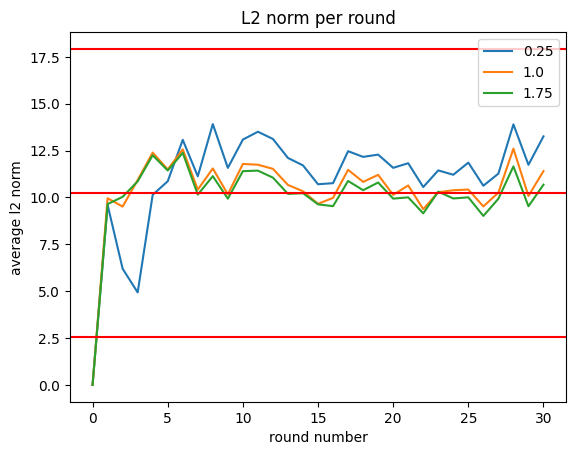

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

plot_clip_coefficient_dict(l2_norms, title='L2 norm per round', xlabel='round number', ylabel='average l2 norm', ax=ax)

for clip_coefficient in l2_norms.keys():
  ax.axhline(clip_coefficient * mu, color = 'red')

As discussed earlier, the norms of 0.25 coefficient are quite expected because I would expect it to never clip the gradients. It also looks like the norms of 1.75 coefficient are slightly lower because it always clips the gradients.

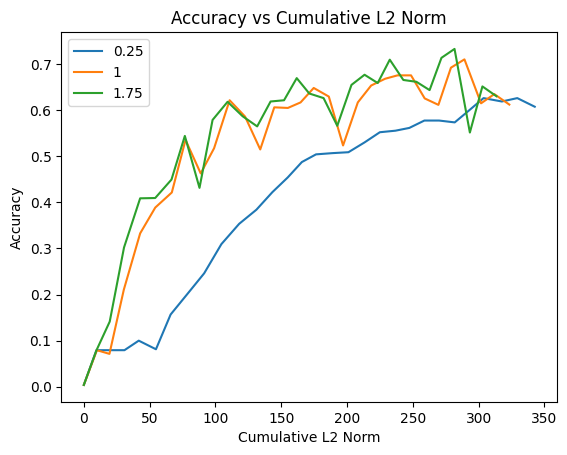

In [31]:
import matplotlib.pyplot as plt
from itertools import accumulate

cumulative_l2_norms = {
    key: list(accumulate([v for _, v in values])) for key, values in l2_norms.items()
}

fig, ax = plt.subplots()

for key in cumulative_l2_norms.keys():
    if key in accuracies:
        ax.plot(cumulative_l2_norms[key], [v[1] for v in accuracies[key]], label=f'{key}')

ax.set_xlabel('Cumulative L2 Norm')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Cumulative L2 Norm')
ax.legend()

plt.show()

2. How do the L2 norms of the federated model deltas compare against the change in accuracy between rounds? Is the relationship predictable and/or linear? Consider all the `clip_norm` values you have tried in your response and provide potential explanations for why/why not the relationship between accuracy and cumulative L2 changes between bounds.

{0.25: [0.07533333333333334, 0.0, 0.0, 0.0, 0.020666666666666667, -0.01866666666666668, 0.07533333333333335, 0.048666666666666664, 0.040666666666666657, 0.06333333333333335, 0.043999999999999984, 0.030666666666666675, 0.03799999999999998, 0.03200000000000003, 0.033333333333333326, 0.016666666666666663, 0.002666666666666706, 0.0020000000000000018, 0.021333333333333315, 0.02200000000000002, 0.0033333333333332993, 0.006000000000000005, 0.016000000000000014, 0.0, -0.0040000000000000036, 0.02533333333333332, 0.02733333333333332, -0.007333333333333303, 0.007333333333333303, -0.01866666666666672], 1: [0.07533333333333334, -0.008000000000000007, 0.13933333333333334, 0.122, 0.055999999999999994, 0.03266666666666668, 0.11399999999999999, -0.07266666666666666, 0.05466666666666664, 0.10399999999999998, -0.03533333333333333, -0.07133333333333325, 0.09133333333333327, -0.0013333333333332975, 0.01200000000000001, 0.031333333333333324, -0.01866666666666672, -0.10599999999999998, 0.09333333333333338, 0

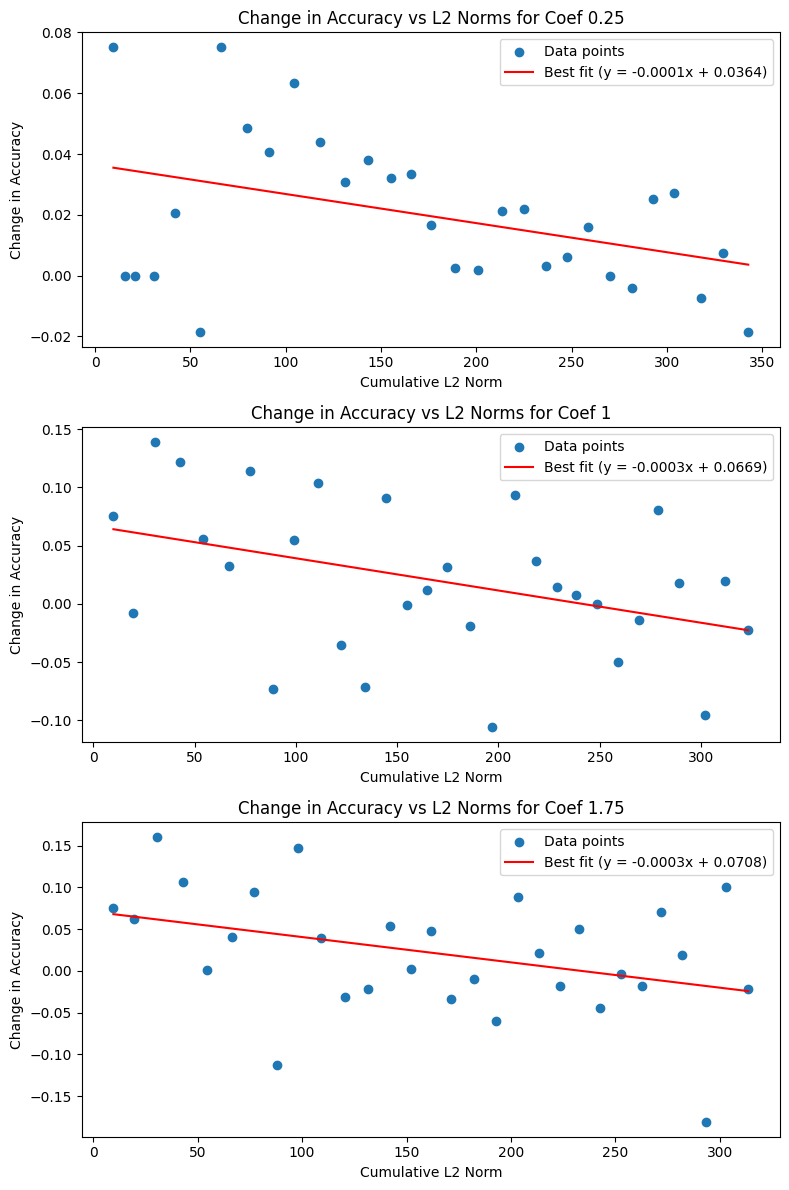

In [50]:
import matplotlib.pyplot as plt
import numpy as np

accuracy_changes = {
    key: [j[1] - i[1] for i, j in zip(values[:-1], values[1:])] for key, values in accuracies.items()
}
print(accuracy_changes)
print(cumulative_l2_norms)

fig, axs = plt.subplots(len(l2_norms), 1, figsize=(8, 12))

for idx, (key, values) in enumerate(cumulative_l2_norms.items()):
    if key in accuracy_changes:
        # Create scatter plot
        axs[idx].scatter(values, accuracy_changes[key], label=f'Data points')
        
        # Calculate and add best fit line
        if len(values) > 1:  # Need at least 2 points for a line
            x = np.array(values)
            y = np.array(accuracy_changes[key])
            
            # Calculate the linear regression (first degree polynomial)
            slope, intercept = np.polyfit(x, y, 1)
            
            # Create line points
            x_line = np.linspace(min(x), max(x), 100)
            y_line = slope * x_line + intercept
            
            # Plot the line
            axs[idx].plot(x_line, y_line, 'r-', label=f'Best fit (y = {slope:.4f}x + {intercept:.4f})')
        
        axs[idx].set_title(f'Change in Accuracy vs L2 Norms for Coef {key}')
        axs[idx].set_xlabel('Cumulative L2 Norm')
        axs[idx].set_ylabel('Change in Accuracy')
        axs[idx].legend()

plt.tight_layout()
plt.show()

According to the graphs, there seems to be not much correlation (at least linear correlation) between change in accuracy and cumulative L2 Norm. However, for the first graph (0.25 coefficient), we can see a linear correlation, especially if we disregard the first few points, when the model is stabilising.

My hypothesis is that when gradients are clipped, the direct relationship between the magnitude of the gradient (reflected in the L2 norm) and the model update step is altered. Hence for the 0.25 coefficient, where clippings almost never happen, the relationship is the most pronounced.

## 3.2 Adaptive Norm Bound DP


Having investigated the impact of gradient clipping with a fixed norm on performance, you may wonder if your chosen norm will stay appropriate for the entire training.

To avoid perfectly tuning a fixed `clip_norm` an [adaptive version of DPFedAvg](https://arxiv.org/abs/1905.03871) was proposed in paper \[3], which attempts to automatically scale the bound on the L2 norm of model updates based on a quantile of L2 norms provided by clients in a given round. As computing such a value would be computationally expensive and require clients to send private values, the paper proposes an algorithm meant to approximate the quantile.

Specifically, it adjusts the `clip_norm` parameter as:

>     self.clip_norm *= math.exp(-self.clip_norm_lr

            * (noised_clients_with_clipped_norm_fraction - self.clip_norm_target_quantile)
        )

where the new clip norm depends on a learning rate, the fraction of clients used in training who have clipped their norms (with added noise), and the target quantile. In the code below, the clients who have clipped their norm are reported via a set bit in the config, and thus `noised_clients_with_clipped_norm_fraction` is replaced with `noised_norm_bit_set_fraction`. By knowing approximately how many clients fall below a given norm, we can iteratively improve the `clip_norm` until the percentage of clients with norms smaller than the bound is reached.

The new implementation is hard to use and balance for short experiments such as ours as it includes an initial phase where the norm grows exponentially in its attempts to converge to the actual quantile. Given that we do not want any further interference making the behaviour of DP harder to predict, this would prove inconvenient when trying to deduce the impact of noise. As such, we shall only track the behaviour of the adaptive norm and use the predictable `DPFedAvgFixed` when experimenting with obtaining a given level of $\epsilon$ privacy.


In [35]:
"""DP-FedAvg [Andrew et al., 2019] with adaptive clipping.
Paper: https://arxiv.org/pdf/1905.03871.pdf
"""

# Original implementation by Vasundhara Agarwal


class DPFedAvgAdaptive(DPFedAvgFixed):
    """Server-side adaptive clipping for DP-FedAvg."""

    # pylint: disable=too-many-arguments,too-many-instance-attributes
    def __init__(
        self,
        *,
        fraction_fit: float = 1.0,
        fraction_evaluate: float = 1.0,
        min_fit_clients: int = 2,
        min_evaluate_clients: int = 2,
        min_available_clients: int = 2,
        evaluate_fn: (
            Callable[
                [int, NDArrays, dict[str, Scalar]],
                tuple[float, dict[str, Scalar]] | None,
            ]
            | None
        ) = None,
        on_fit_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        on_evaluate_config_fn: Callable[[int], dict[str, Scalar]] | None = None,
        accept_failures: bool = False,
        initial_parameters: Parameters | None = None,
        fit_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        evaluate_metrics_aggregation_fn: MetricsAggregationFn | None = None,
        server_learning_rate: float = 1.0,
        server_momentum: float = 0.0,
        num_clients_per_round: int,
        init_clip_norm: float = 0.1,
        noise_multiplier: float = 1,
        server_side_noising: bool = True,
        clip_norm_lr: float = 0.2,
        clip_norm_target_quantile: float = 0.5,
        clip_count_stddev: float | None = None,
    ) -> None:
        super().__init__(
            fraction_fit=fraction_fit,
            fraction_evaluate=fraction_evaluate,
            min_fit_clients=min_fit_clients,
            min_evaluate_clients=min_evaluate_clients,
            min_available_clients=min_available_clients,
            evaluate_fn=evaluate_fn,
            on_fit_config_fn=on_fit_config_fn,
            on_evaluate_config_fn=on_evaluate_config_fn,
            accept_failures=accept_failures,
            initial_parameters=initial_parameters,
            fit_metrics_aggregation_fn=fit_metrics_aggregation_fn,
            evaluate_metrics_aggregation_fn=evaluate_metrics_aggregation_fn,
            server_learning_rate=server_learning_rate,
            server_momentum=server_momentum,
            num_clients_per_round=num_clients_per_round,
            clip_norm=init_clip_norm,
            noise_multiplier=noise_multiplier,
            server_side_noising=server_side_noising,
        )
        self.clip_norm_lr = clip_norm_lr
        self.clip_norm_target_quantile = clip_norm_target_quantile
        self.clip_count_stddev = clip_count_stddev

        # Decides the level of noise added to the fraction of clients which have clipped
        # their norms
        if self.clip_count_stddev is None:
            self.clip_count_stddev = 0
            if noise_multiplier > 0:
                self.clip_count_stddev = self.num_clients_per_round / 20.0

        if noise_multiplier:
            self.noise_multiplier = (
                self.noise_multiplier ** (-2) - (2 * self.clip_count_stddev) ** (-2)
            ) ** (-0.5)

    def configure_fit(
        self, server_round: int, parameters: Parameters, client_manager: ClientManager
    ) -> list[tuple[ClientProxy, FitIns]]:
        """Configure the next round of training."""
        additional_config = {"dpfedavg_adaptive_clip_enabled": True}

        client_instructions = super().configure_fit(
            server_round, parameters, client_manager
        )

        for _, fit_ins in client_instructions:
            fit_ins.config.update(additional_config)

        return client_instructions

    def _update_clip_norm(self, results: list[tuple[ClientProxy, FitRes]]) -> None:
        """Update the clipping norm based on the fraction of clients which clipped."""
        # Calculating number of clients which set the norm indicator bit
        norm_bit_set_count = 0
        for client_proxy, fit_res in results:
            if "dpfedavg_norm_bit" not in fit_res.metrics:
                raise DPClientNormBitError(
                    f"Indicator bit not returned by client with id {client_proxy.cid}."
                )

            if fit_res.metrics["dpfedavg_norm_bit"]:
                norm_bit_set_count += 1
        # Noising the count
        noised_norm_bit_set_count = float(
            np.random.normal(norm_bit_set_count, self.clip_count_stddev)
        )

        noised_norm_bit_set_fraction = noised_norm_bit_set_count / len(results)
        # Geometric update
        self.clip_norm *= math.exp(
            -self.clip_norm_lr
            * (noised_norm_bit_set_fraction - self.clip_norm_target_quantile)
        )

    def aggregate_fit(
        self,
        server_round: int,
        results: list[tuple[ClientProxy, FitRes]],
        failures: list[tuple[ClientProxy, FitRes] | BaseException],
    ) -> tuple[Parameters | None, dict[str, Scalar]]:
        """Aggregate the results of the training round."""
        if not self.accept_failures and failures:
            return None, {}
        new_global_model, metrics = super().aggregate_fit(
            server_round, results, failures
        )
        self._update_clip_norm(results)
        metrics["adaptive_clip_norm"] = self.clip_norm
        return new_global_model, metrics

In [36]:
# New function to run the adaptive norm experiments with sensible defaults

dp_client_generator = get_dp_client_generator(
    network_generator_cnn,
    data_dir,
    federated_partition,
    lambda x: client_samples_dataframe.cid[x],
)


adaptive_default_parameters: dict = {
    "train_config": get_default_train_config(),
    "test_config": get_default_test_config(),
    "num_total_clients": num_total_clients,
    "num_clients_per_round": 4,
    "num_evaluate_clients": 0,
    "num_evaluate": 0,
    "accept_failures": False,
    "min_fit_clients": 2,
    "min_available_clients": 2,
    "initial_parameters": ndarrays_to_parameters(seed_model_cnn_params),
    "client_generator": dp_client_generator,
    "seed": Seeds.DEFAULT,
    "num_rounds": 30,
    "strategy": DPFedAvgAdaptive,
    "fed_eval": True,
    "server_side_noising": True,
    "clip_count_stddev": None,
}


def run_dp_adaptive_fl(
    noise_multiplier: float = 0,
    init_clip_norm: float = 2,
    clip_norm_lr: float = 0.2,
    clip_norm_target_quantile: float = 0.5,
    default_parameters: dict = adaptive_default_parameters,
    **kwargs: dict[str, Any],
) -> Any:
    """Execute a DP-FedAvg simulation with adaptive clipping."""
    parameters: dict = {**default_parameters, **kwargs}

    def on_fit_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["train_config"]

    def on_evaluate_config_fn(cid: int) -> dict[str, Scalar]:
        return parameters["test_config"]

    fraction_fit: float = (
        float(parameters["num_clients_per_round"]) / parameters["num_total_clients"]
    )
    fraction_evaluate: float = (
        float(parameters["num_evaluate_clients"]) / parameters["num_total_clients"]
    )

    strategy = parameters["strategy"](
        num_clients_per_round=parameters["num_clients_per_round"],
        fraction_fit=fraction_fit,
        fraction_evaluate=fraction_evaluate,
        min_fit_clients=parameters["min_fit_clients"],
        min_available_clients=parameters["min_available_clients"],
        on_fit_config_fn=on_fit_config_fn,
        on_evaluate_config_fn=on_evaluate_config_fn,
        initial_parameters=parameters["initial_parameters"],
        accept_failures=parameters["accept_failures"],
        evaluate_fn=(
            federated_evaluation_function if parameters["fed_eval"] is True else None
        ),
        fit_metrics_aggregation_fn=aggregate_weighted_average,
        evaluate_metrics_aggregation_fn=aggregate_weighted_average,
        init_clip_norm=init_clip_norm,
        clip_norm_lr=clip_norm_lr,
        clip_norm_target_quantile=clip_norm_target_quantile,
        noise_multiplier=noise_multiplier,
        server_side_noising=parameters["server_side_noising"],
        clip_count_stddev=parameters["clip_count_stddev"],
    )
    client_manager = CustomClientManager(criterion=None, seed=parameters["seed"])
    server = Server(
        client_manager=client_manager,
        strategy=strategy,
    )
    return start_seeded_simulation(
        client_fn=lambda cid: parameters["client_generator"](cid).to_client(),
        num_clients=parameters["num_total_clients"],
        server=server,
        config=ServerConfig(num_rounds=parameters["num_rounds"]),
        strategy=strategy,
        seed=parameters["seed"],
        name=f"adaptive_target_{clip_norm_target_quantile}_init_clip_norm_{init_clip_norm}_lr_{clip_norm_lr}_noise_{noise_multiplier}",
    )

In [37]:
parameters_for_every_round_adaptive, hist_adaptive_quantile_0_5 = run_dp_adaptive_fl(
    clip_norm_target_quantile = 0.5, noise_multiplier = 0
)

WARNING flwr 2025-02-24 14:12:49,476 | app.py:213 | Both server and strategy were provided, ignoring strategy
INFO flwr 2025-02-24 14:12:49,477 | app.py:149 | Starting Flower simulation, config: ServerConfig(num_rounds=30, round_timeout=None)
INFO flwr 2025-02-24 14:12:49,484 | server_returns_parameters.py:81 | Initializing global parameters
INFO flwr 2025-02-24 14:12:49,485 | server_returns_parameters.py:273 | Using initial parameters provided by strategy
INFO flwr 2025-02-24 14:12:49,489 | server_returns_parameters.py:84 | Evaluating initial parameters
100%|██████████| 47/47 [00:00<00:00, 123.87it/s]
INFO flwr 2025-02-24 14:12:49,876 | server_returns_parameters.py:87 | initial parameters (loss, other metrics): 194.3757643699646, {'accuracy': 0.004}
INFO flwr 2025-02-24 14:12:49,876 | server_returns_parameters.py:97 | FL starting
INFO flwr 2025-02-24 14:12:49,878 | client_manager.py:43 | Sampling using None
INFO flwr 2025-02-24 14:12:49,879 | client_manager.py:68 | Sampled the followi

Having gone through this slight detour to understand how we could obtain an adaptive bound which leaves the privacy budget mostly undisturbed without experimentation, we shall return to DP's primary goal, matching a given theoretical bound on privacy. However, Part III and MPhil students will now get to play around and observe the behaviour of this adaptive norm algorithm.


# 4 Epsilon-delta Privacy


We are now ready to understand the full extent of the DPFedAvg fixed algorithm and the relation between its privacy guarantees and the accuracy of the final model.

Before this, we should establish what a particular set of DP parameters implies for the level of privacy theoretically. The function below shall allow us to do just that while assuming a fixed number of rounds and clients per round. It adapts a function provided by TensorFlow privacy for DP-SGD, as we have established that DP-FedAvg and DP-SGD are equivalent when considering a mere reframing of samples as clients; it should provide sufficient accuracy for our purposes.


In [38]:
from tensorflow_privacy.privacy.analysis.compute_dp_sgd_privacy_lib import (
    compute_dp_sgd_privacy,
)
from contextlib import redirect_stdout
from io import StringIO


class NullIO(StringIO):
    """Custom IO interface to cut-out annoying messages."""

    def write(self, txt: str) -> None:
        """Implement custom empty write function."""
        # This function intentionally does nothing


def compute_fl_privacy(
    num_rounds: int = 25,
    noise_multiplier: float = 1.0,
    num_total_clients: int = num_total_clients,
    num_fit_clients: int = 4,
) -> float:
    """Compute the privacy bound `epsilon`."""
    with redirect_stdout(NullIO()):
        vals = compute_dp_sgd_privacy(
            n=num_total_clients,
            batch_size=num_fit_clients,
            noise_multiplier=noise_multiplier,
            epochs=num_rounds,
            delta=num_total_clients ** (-1),
        )
    return vals[0]

In [39]:
log(INFO, compute_fl_privacy(noise_multiplier=0.05))
log(INFO, compute_fl_privacy(noise_multiplier=1.0))

INFO flwr 2025-02-24 14:14:22,629 | 3928211183.py:1 | 4363302.374442753
INFO flwr 2025-02-24 14:14:22,648 | 3928211183.py:2 | 0.754153696738303


**Question 7 (Part II ✅ | Part III/MPhil ✅):**

(While this is a largely conceptual question, it does require you to provide a small amount of **code** and several **plots**. Answers to the purely conceptual components should contain **no more than 5 sentences**.)

Using the function mentioned above, study the impact of different parameters on the privacy guarantees of DP-FedAvg as follows:

1. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary the noise multiplier from 0.05 to 2 using an increment of 0.05. Use the noise multiplier as the x-axis.

2. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary `num_rounds` between $2^0$ and $2^{15}$ increasing using all the powers of two in the interval. Use the `num_rounds` as the x-axis.

3. Draw a scatter plot with the epsilon value on the y-axis. While keeping all the other parameters constant to the above values, vary `num_fit_cliets` from $2^0$ to $2^{10}$ increasing using all the powers of two in the interval. Use the `num_fit_cliets` as x-axis.

4. Describe the trade-offs you see and how they relate to FL privacy. <!-- Then, given the lecture by Peter Kairouz, what do you think the implications of these trade-offs are upon the practicality of Differential Privacy in FL? --> Then, what do you think are the implications of these trade-offs upon the practicality of differential privacy in FL?


In [40]:
import matplotlib.pyplot as plt

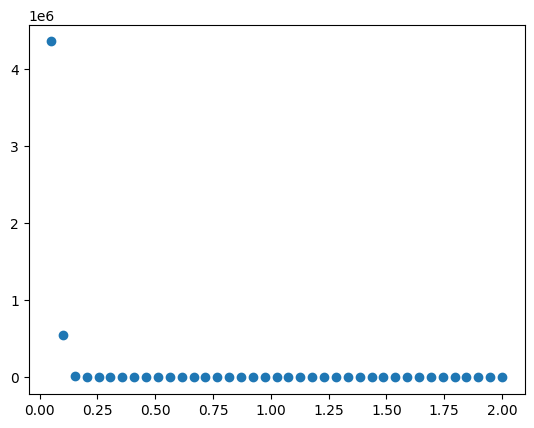

In [41]:
start = 0.05
stop = 2
step = 0.05
num = int((stop - start) // step + 1)
noise_multipliers = np.linspace(0.05, 2, num)
privacy_values = np.array(list(map(lambda x: compute_fl_privacy(noise_multiplier = x), noise_multipliers)))

plt.scatter(
    noise_multipliers,
    privacy_values,
)

This graph does not indicate much, I tried plotting the same graph while setting num_rounds and num_fit_clients to the extreme cases from the following 2 plots (2^15 and 2^10 respectively).

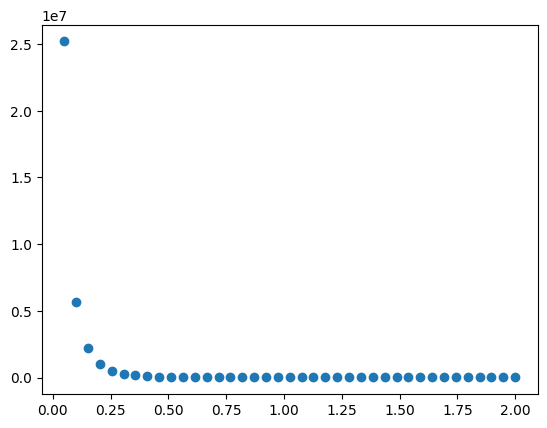

In [42]:
start = 0.05
stop = 2
step = 0.05
num = int((stop - start) // step + 1)
noise_multipliers = np.linspace(0.05, 2, num)
privacy_values = np.array(list(map(lambda x: compute_fl_privacy(noise_multiplier = x, num_fit_clients = 2**10, num_rounds = 2**15), noise_multipliers)))

plt.scatter(
    noise_multipliers,
    privacy_values,
)

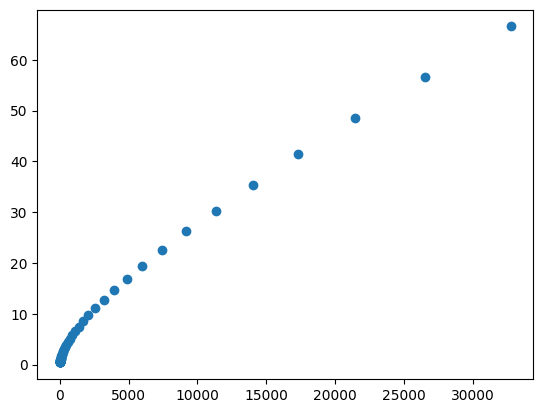

In [43]:
num_rounds = np.logspace(0, 15, base=2)
privacy_values_rounds = np.array(list(map(lambda x: compute_fl_privacy(num_rounds = x), num_rounds)))

plt.scatter(
    num_rounds,
    privacy_values_rounds,
)

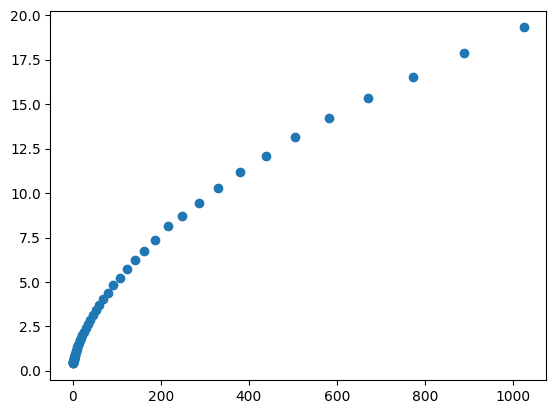

In [44]:
num_fit_clients = np.logspace(0, 10, base=2)
privacy_values_fit_clients = np.array(list(map(lambda x: compute_fl_privacy(num_fit_clients = x), num_fit_clients)))

plt.scatter(
    num_fit_clients,
    privacy_values_fit_clients,
)

4.
In short:
- Increasing amount of noise linearly improves privacy exponentially
- Increasing number of rounds worsens privacy
- Increasing number of clients worsens privacy

The ideas behind these tradeoffs are outlined as:
- Accuracy (decreases with more noise) vs Privacy
- Model convergence (better convergence requires more rounds) vs Privacy
- Size of dataset (increases with number of clients) vs Privacy

Hence the amount of privacy that should be preserved depends on the use-case of the model. In sectors like healthcare, where privacy should be high, if the particular model can afford to have lower accuracy or accomodate less clients, the creators of the model should probably strike that balance. 

Armed with this theoretical understanding of the privacy budget, we can explore the performance implications of Differential Privacy upon DPFedAvgFixed. Note once more that the experiments we are running are small scale, as such you may find particularly high sensitivity to the `noise_multiplier` to be present.


**Question 8 (Part II ✅ | Part III/MPhil ✅):**

(You need to provide the answer with **code** and **plots** for this question. A short written argumentation is recommended.)

Using the results of the previous experiment, observe the impact that a given noise multiplier has on both performance and privacy when using a **fixed** norm bound.

1. Set a `noise_multiplier`$\in \{0.1\}$ while keeping all other parameters constant. Then run the FL simulation using the `DPFedAvgFixed` strategy from above.


In [45]:
params, hist_clip_bound_4_noise_0_01 = run_dp_fixed_fl(noise_multiplier = 0.1)

WARNING flwr 2025-02-24 14:14:30,513 | app.py:213 | Both server and strategy were provided, ignoring strategy
INFO flwr 2025-02-24 14:14:30,515 | app.py:149 | Starting Flower simulation, config: ServerConfig(num_rounds=30, round_timeout=None)
INFO flwr 2025-02-24 14:14:30,523 | server_returns_parameters.py:81 | Initializing global parameters
INFO flwr 2025-02-24 14:14:30,526 | server_returns_parameters.py:273 | Using initial parameters provided by strategy
INFO flwr 2025-02-24 14:14:30,528 | server_returns_parameters.py:84 | Evaluating initial parameters
100%|██████████| 47/47 [00:00<00:00, 158.52it/s]
INFO flwr 2025-02-24 14:14:30,830 | server_returns_parameters.py:87 | initial parameters (loss, other metrics): 194.3757643699646, {'accuracy': 0.004}
INFO flwr 2025-02-24 14:14:30,830 | server_returns_parameters.py:97 | FL starting
INFO flwr 2025-02-24 14:14:30,832 | client_manager.py:43 | Sampling using None
INFO flwr 2025-02-24 14:14:30,832 | client_manager.py:68 | Sampled the followi

2. Plot accuracy and compare the convergence curves against the results you have for the previous experiment with a multiplier of $0.05$ (`hist_clip_bound_4_noise_0_05`). _NOTE: it was done just after defining the aforementioned strategy._

In [46]:
accuracies_per_noise = {}
for noise_multiplier, h in [(0.1, hist_clip_bound_4_noise_0_01), (0.05,hist_clip_bound_4_noise_0_05)]:
  accuracies_per_noise[noise_multiplier] = h.metrics_centralized['accuracy']

3. Use the `compute_fl_privacy` function to compute the epsilon value of two noise levels mentioned above. How does the epsilon of a given noise level relate to the accuracy achieved by that model? Does the relationship between the two fit your expectations from the question above?

<Axes: title={'center': 'Accuracies per round'}, xlabel='round number', ylabel='accuracy'>

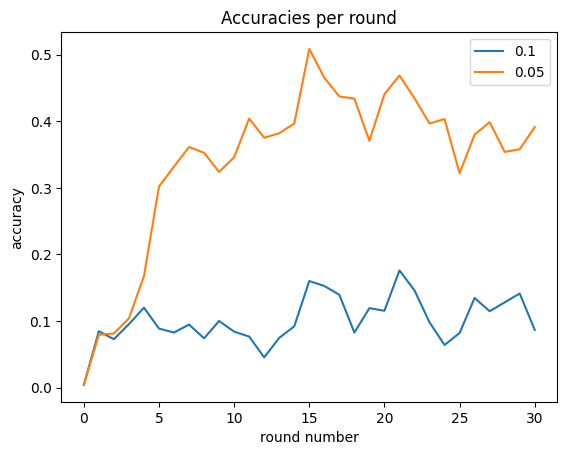

In [47]:
plot_clip_coefficient_dict(accuracies_per_noise, title='Accuracies per round', xlabel='round number', ylabel='accuracy')

Increasing noise should indeed lower accuracy. This is within expectations.

In [48]:
compute_fl_privacy(noise_multiplier = 0.01), compute_fl_privacy(noise_multiplier = 0.05)

(125263302.37444276, 4363302.374442753)

# End of Part I

Continue to part 2.


(c) 2024 Alexandru-Andrei Iacob, Lorenzo Sani
